# CRNN Training Research

This notebook shows the training of the custom CRNN to recognize strips of scores. (discarded approach)

In [1]:
import os
import sys
from pathlib import Path
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import importlib

PROJECT_ROOT = Path().resolve().parent  # adjust if notebook is nested
sys.path.insert(0, str(PROJECT_ROOT))

from models.crnn.model_class import CRNN, CRNN2
from models.crnn.model_eval import real_data_eval
from scripts.training import train_step, evaluate
from scripts.utils import load_checkpoint

## EXP 1 : CRNN 1.0 with dataset class 1.0

Datasets `set0`, `set1` have been used in this section.

- 1.1 - `set0` from `syn_dataset.ipynb` is a failed version with gradients unable to flow during training. Shapes has `thickness = 2` which is too much, no superscripts used.
- 1.2 - `set1` from `syn_dataset2.ipynb` refines shapes to have `thickness = 1` and enlarged superscripts, gradients started to flow. Random width compression is later added for sample width robustness.

### EXP 1.1

Average CER: 0.431 on 15 epochs

In [2]:
from scripts.dataset_class import ScorecardDataset, scorecard_collate_fn, Tokenizer, load_dataset

tokenizer = Tokenizer()
num_classes = len(tokenizer.alphabet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(num_classes).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adadelta(model.parameters())

Dataset split complete: 11400 train, 600 test.


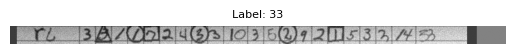

In [3]:
use_set = 'set0'
n = None
dataset_img_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "images")
dataset_lbl_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "labels")

img_paths, label_paths = load_dataset(dataset_img_path, dataset_lbl_path, n)
train_img_paths, test_img_paths, train_lbl_paths, test_lbl_paths = train_test_split(img_paths, label_paths, test_size=0.05, random_state=42, shuffle=True)

train_dataset = ScorecardDataset(train_img_paths, train_lbl_paths, tokenizer.char2idx)
test_dataset = ScorecardDataset(test_img_paths, test_lbl_paths, tokenizer.char2idx)
trainloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=scorecard_collate_fn)
testloader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=scorecard_collate_fn)

print(f"Dataset split complete: {len(train_dataset)} train, {len(test_dataset)} test.")

# Visualize 1 pair or image-label
batch = next(iter(trainloader))
images, targets, input_lengths, target_lengths = batch
img = images[0]
img = img.squeeze(0)
plt.imshow(img.numpy(), cmap='gray')
plt.title(f"Label: {targets[0]}", fontsize=8); plt.axis('off'); plt.show()

In [4]:
epochs = 15
train_losses, val_losses = [], []
best_val_loss = float('inf')
for e in range(epochs):
    train_loss = train_step(model, trainloader, optimizer, criterion, device)
    val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"--- Epoch {e} --- Train loss: {train_loss:.4f} | Validation loss: {val_loss:.4f} | cer: {val_acc:.3f}")
    # if (e+1)%50 == 0:
    # print(val_examples.to_string())

  0%|          | 0/2850 [00:00<?, ?it/s]

100%|██████████| 2850/2850 [04:49<00:00,  9.85it/s]


--- Epoch 0 --- Train loss: 1.5760 | Validation loss: 0.9651 | cer: 0.330


100%|██████████| 2850/2850 [02:27<00:00, 19.38it/s]


--- Epoch 1 --- Train loss: 0.3797 | Validation loss: 0.3140 | cer: 0.122


...

--- Epoch 12 --- Train loss: 0.1626 | Validation loss: 0.1648 | cer: 0.046


100%|██████████| 2850/2850 [02:30<00:00, 18.88it/s]


--- Epoch 13 --- Train loss: 0.1587 | Validation loss: 0.1629 | cer: 0.046


100%|██████████| 2850/2850 [02:25<00:00, 19.62it/s]


--- Epoch 14 --- Train loss: 0.1546 | Validation loss: 0.1632 | cer: 0.045


In [9]:
checkpoint = {
    "epoch": epochs,  # current epoch number
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_losses,
    "validation_loss": val_losses,
    "description": '' 
}

save_name = "crnn_set0_N-all"
save_path = os.path.join(PROJECT_ROOT, "weights", )
os.makedirs(save_path, exist_ok=True)
cp_name = "checkpoint-15ep"
torch.save(checkpoint, os.path.join(save_path, f"{cp_name}.pt"))

In [6]:
val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
for i, row in val_examples.sample(10).iterrows():
    print(f"GT: \t {row['Ground Truth']}")
    print(f"Pred: \t {row['Predicted']}")
    print()

GT: 	 FP||+7|^1|8|8|1|+7|9|7|^5|13|^7|6|7|2|2|3|1|3|5|9|18
Pred: 	 HF||+7|^1|8|8|1|+7|9|7|^5|13|^7|6|7|2|2|3|1|3|5|9|18

GT: 	 FVN|3|6|7|1|1|4|+5|^4|+4|8|13|4|^3|3|^7|5|^2|6|6|1|12|27
Pred: 	 VM|3|6|7|1|1|4|+5|^4|+4|8|13|4|^3|3|^7|5|^2|6|6|1|12|27

GT: 	 IOO|12|8|9|5|9|5|2|7|2|8|12|2|3|1|3|7|3|1|2|8|14|13
Pred: 	 KO|12|8|9|5|7|5|2|7|2|8|12|2|3|1|3|7|3|1|2|8|14|13

GT: 	 LD||8|3|8|6|4|6|9|9|5|14|9|8|1|9|8|6|4|4|3|4|29
Pred: 	 H||8|3|8|6|4|6|9|9|5|14|9|8|1|9|8|6|4|4|3|4|28

GT: 	 RH|16|4|5|4|2|8|9|+1|1|3|13|8|3|3|2|4|9|5|3|5|5|34
Pred: 	 HL|16|4|5|4|2|8|9|+1|1|3|13|8|3|3|2|4|9|5|3|5|5|34

GT: 	 FCZ|5|6|+2|5|5|7|4|@5|2|9|12|9|2|@6|5|9|9|9|6|@2|8|34
Pred: 	 ZS|5|6|+2|5|5|7|4|@5|2|9|12|9|2|@6|5|9|9|9|6|@2|8|34

GT: 	 CPX||3|4|@3|6|9|8|@2|4|1|12|1|6|2|^1|@8|+7|4|2|9|6|32
Pred: 	 O||3|4|@3|6|9|8|@2|4|1|12|1|6|2|^1|@8|+7|4|2|9|6|32

GT: 	 KK|14|8|9|1|5|+1|4|3|8|1|10|@8|8|7|4|9|+9|+2|4|+3|7|12
Pred: 	 MV|14|8|9|1|5|+1|4|3|8|1|10|@8|8|7|4|9|+9|+2|4|+3|7|12

GT: 	 BW|8|8|7|4|6|7|1|2|4|2|15|7|4|2|

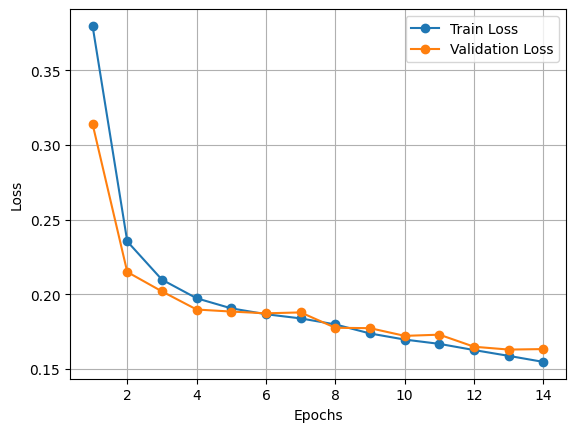

In [10]:
from scripts.utils import see_losses

see_losses(save_name, 1)

In [ ]:
import models.crnn.model_eval
import importlib
importlib.reload(models.crnn.model_eval)
from models.crnn.model_eval import real_data_eval

text_desc = f"""
Model {cp_name} trained on 15 epochs using Synthetic dataset 1.0 with 10k samples.
Shapes with thickness of 2 and without superscripts in images.
"""

real_data_eval(model, criterion, device, tokenizer, save_fig=f"set0_crnn_set0_N-all_15ep", print_text=text_desc)

In [ ]:
# Test with real_dataset2

cp_name = 'checkpoint-15ep'
model, optimizer, checkpoint = load_checkpoint('crnn', 'crnn_set0_N-all', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on 15 epochs using Synthetic dataset 1.0 with 10k samples.
Shapes with thickness of 2 and without superscripts in images.
Test dataset 2.0 used for this evaluation.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset2'),
                         save_fig=f"crnn_set0_N-all_15ep_eval2", print_text=text_desc, show=False)
results

{'N': 52,
 'average_loss': 3.3604004749884973,
 'average_cer': 0.4409834520642285,
 'min_cer': 0.16,
 'max_cer': 0.78}

### EXP 1.2

Average CER: 
- 0.352 at 15 epochs
- 0.307 at 25 epochs

In [14]:
from scripts.dataset_class import ScorecardDataset, scorecard_collate_fn, Tokenizer, load_dataset

tokenizer = Tokenizer()
num_classes = len(tokenizer.alphabet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(num_classes).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adadelta(model.parameters())

In [14]:
model, optimizer, checkpoint = load_checkpoint('crnn', 'crnn_set1_N-10k', 'checkpoint-25ep', num_classes)

Dataset split complete: 9500 train, 500 test.


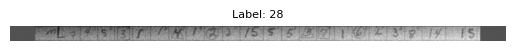

In [11]:
use_set = 'set1'
n = 10000
dataset_img_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "images")
dataset_lbl_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "labels")

img_paths, label_paths = load_dataset(dataset_img_path, dataset_lbl_path, n)
train_img_paths, test_img_paths, train_lbl_paths, test_lbl_paths = train_test_split(img_paths, label_paths, test_size=0.05, random_state=42, shuffle=True)

train_dataset = ScorecardDataset(train_img_paths, train_lbl_paths, tokenizer.char2idx)
test_dataset = ScorecardDataset(test_img_paths, test_lbl_paths, tokenizer.char2idx)
trainloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=scorecard_collate_fn)
testloader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=scorecard_collate_fn)

print(f"Dataset split complete: {len(train_dataset)} train, {len(test_dataset)} test.")

# Visualize 1 pair or image-label
batch = next(iter(trainloader))
images, targets, input_lengths, target_lengths = batch
img = images[0]
img = img.squeeze(0)
plt.imshow(img.numpy(), cmap='gray')
plt.title(f"Label: {targets[0]}", fontsize=8); plt.axis('off'); plt.show()

In [40]:
epochs = 10
train_losses, val_losses = [], []
best_val_loss = float('inf')
for e in range(epochs):
    train_loss = train_step(model, trainloader, optimizer, criterion, device)
    val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"--- Epoch {e} --- Train loss: {train_loss:.4f} | Validation loss: {val_loss:.4f} | cer: {val_acc:.3f}")
    # if (e+1)%50 == 0:
    # print(val_examples.to_string())

100%|██████████| 2375/2375 [02:08<00:00, 18.44it/s]


--- Epoch 0 --- Train loss: 0.2492 | Validation loss: 0.2408 | cer: 0.074


100%|██████████| 2375/2375 [02:08<00:00, 18.42it/s]


--- Epoch 1 --- Train loss: 0.2388 | Validation loss: 0.2350 | cer: 0.067


100%|██████████| 2375/2375 [02:09<00:00, 18.36it/s]


...

--- Epoch 7 --- Train loss: 0.1944 | Validation loss: 0.1961 | cer: 0.063


100%|██████████| 2375/2375 [02:14<00:00, 17.64it/s]


--- Epoch 8 --- Train loss: 0.1855 | Validation loss: 0.1839 | cer: 0.058


100%|██████████| 2375/2375 [02:09<00:00, 18.35it/s]


--- Epoch 9 --- Train loss: 0.1808 | Validation loss: 0.1864 | cer: 0.059


In [41]:
checkpoint = {
    "epoch": epochs + 15,  #
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_losses,
    "validation_loss": val_losses,
    "description": '' 
}

save_path = os.path.join(PROJECT_ROOT, "weights", "crnn_set1_N-10k")
os.makedirs(save_path, exist_ok=True)
cp_name = "checkpoint-25ep"
torch.save(checkpoint, os.path.join(save_path, f"{cp_name}.pt"))

In [ ]:
val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
for i, row in val_examples.sample(10).iterrows():
    print(f"GT: \t {row['Ground Truth']}")
    print(f"Pred: \t {row['Predicted']}")
    print()

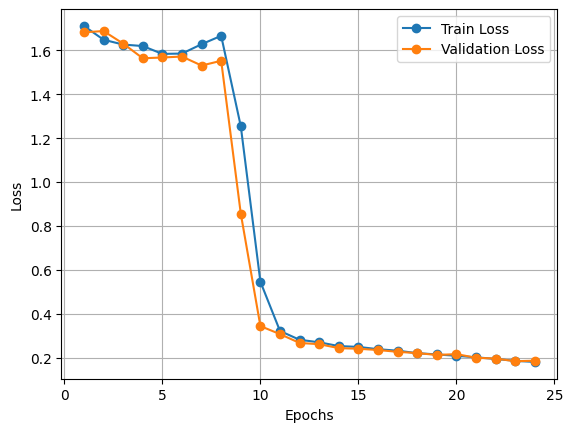

In [43]:
from scripts.utils import see_losses

see_losses("crnn_set1_N-10k", 1)

In [ ]:
from models.crnn.model_eval import real_data_eval

n_epochs = 25
text_desc = f"""
Model {cp_name} trained on {n_epochs} epochs using Synthetic dataset 2.0 with 10k samples.
Shapes with thickness of 1 and superscripts are enabled.
"""

real_data_eval(model, criterion, device, tokenizer, save_fig=f"crnn_set1_N-10k_{n_epochs}ep", print_text=text_desc)

## EXP 2 : CRNN 1.0 with dataset class 2.0

Datasets `set2` is used in this section.

- `set2` is an extension of `set1` that includes an upgraded header, more space at the end and more variability in drawing circles.

### EXP 2.1 : trains on 10k samples to compare with previous experiments.

Average CER:
- 0.300 at 15 epochs
- 0.290 at 25 epochs

In [9]:
from scripts.dataset_class import ScorecardDataset, scorecard_collate_fn, Tokenizer, load_dataset
# importlib.reload(sys.modules['models.crnn.model_class'])
# from models.crnn.model_class import CRNN2

tokenizer = Tokenizer()
num_classes = len(tokenizer.alphabet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(num_classes).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adadelta(model.parameters())

In [13]:
# Test with real_dataset2

cp_name = 'checkpoint-15ep'
model, optimizer, checkpoint = load_checkpoint('crnn', 'crnn_set2_N-10k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on 15 epochs using Synthetic dataset 2.0 with 10k samples.
Test dataset 2.0 used for this evaluation.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset2'),
                         save_fig=f"crnn_set2_N-10K_15ep_eval2", print_text=text_desc, show=False)
results

{'N': 52,
 'average_loss': 1.719806120945857,
 'average_cer': 0.29582400289389,
 'min_cer': 0.12,
 'max_cer': 0.5961538461538461}

In [ ]:
E = 25
cp_name = f'checkpoint-{E}ep'
model, optimizer, checkpoint = load_checkpoint('crnn', 'crnn_set2_N-10k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on {E} epochs using Synthetic dataset 2.0 with 10k samples.
Test dataset 2.0 used for this evaluation.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset2'),
                         save_fig=f"crnn_set2_N-10K_{E}ep_eval2", print_text=text_desc, show=False)
results

E:\work\Golf\GolfScoreCards\models\crnn\model_eval.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.8, 1, 1])


{'N': 52,
 'average_loss': 1.466642778653365,
 'average_cer': 0.27873121974936266,
 'min_cer': 0.07692307692307693,
 'max_cer': 0.62}

In [ ]:
model, optimizer, checkpoint = load_checkpoint('crnn', 'crnn_set2_N-10k', 'checkpoint-15ep', num_classes)

Dataset split complete: 9500 train, 500 test.


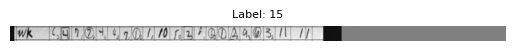

In [ ]:
use_set = 'set2'
n = 10000
dataset_img_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "images")
dataset_lbl_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "labels")

img_paths, label_paths = load_dataset(dataset_img_path, dataset_lbl_path, n)
train_img_paths, test_img_paths, train_lbl_paths, test_lbl_paths = train_test_split(img_paths, label_paths, test_size=0.05, random_state=42, shuffle=True)

train_dataset = ScorecardDataset(train_img_paths, train_lbl_paths, tokenizer.char2idx)
test_dataset = ScorecardDataset(test_img_paths, test_lbl_paths, tokenizer.char2idx)
trainloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=scorecard_collate_fn)
testloader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=scorecard_collate_fn)

print(f"Dataset split complete: {len(train_dataset)} train, {len(test_dataset)} test.")

# Visualize 1 pair or image-label
batch = next(iter(trainloader))
images, targets, input_lengths, target_lengths = batch
img = images[0]
img = img.squeeze(0)
plt.imshow(img.numpy(), cmap='gray')
plt.title(f"Label: {targets[0]}", fontsize=8); plt.axis('off'); plt.show()

In [ ]:
epochs = 10
train_losses, val_losses = [], []
best_val_loss = float('inf')
for e in range(epochs):
    train_loss = train_step(model, trainloader, optimizer, criterion, device)
    val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"--- Epoch {e} --- Train loss: {train_loss:.4f} | Validation loss: {val_loss:.4f} | cer: {val_acc:.3f}")
    # if (e+1)%50 == 0:
    # print(val_examples.to_string())

100%|██████████| 2375/2375 [02:13<00:00, 17.80it/s]


--- Epoch 0 --- Train loss: 0.1619 | Validation loss: 0.1679 | cer: 0.046


100%|██████████| 2375/2375 [02:20<00:00, 16.94it/s]


--- Epoch 1 --- Train loss: 0.1554 | Validation loss: 0.1602 | cer: 0.046


100%|██████████| 2375/2375 [02:15<00:00, 17.50it/s]


...

--- Epoch 7 --- Train loss: 0.1631 | Validation loss: 0.1730 | cer: 0.062


100%|██████████| 2375/2375 [02:15<00:00, 17.51it/s]


--- Epoch 8 --- Train loss: 0.1501 | Validation loss: 0.1621 | cer: 0.060


100%|██████████| 2375/2375 [02:20<00:00, 16.87it/s]


--- Epoch 9 --- Train loss: 0.1411 | Validation loss: 0.1493 | cer: 0.058


In [ ]:
checkpoint = {
    "epoch": epochs + 15,  #
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_losses,
    "validation_loss": val_losses,
    "description": '' 
}

save_path = os.path.join(PROJECT_ROOT, "weights", "crnn_set2_N-10k")
os.makedirs(save_path, exist_ok=True)
cp_name = "checkpoint-25ep"
torch.save(checkpoint, os.path.join(save_path, f"{cp_name}.pt"))

In [ ]:
val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
for i, row in val_examples.sample(10).iterrows():
    print(f"GT: \t {row['Ground Truth']}")
    print(f"Pred: \t {row['Predicted']}")
    print()

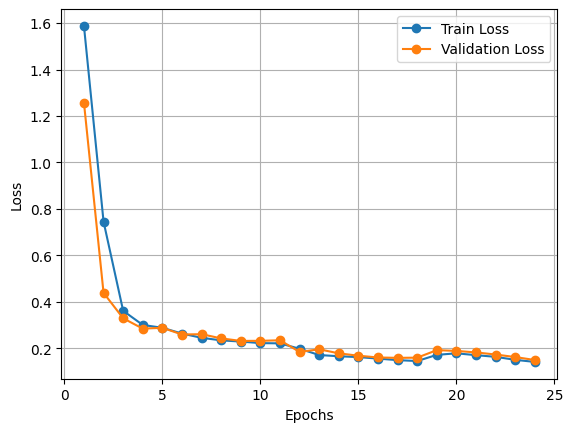

In [ ]:
from scripts.utils import see_losses

see_losses("crnn_set2_N-10k", 1)

In [ ]:
from models.crnn.model_eval import real_data_eval

n_epochs = 25
text_desc = f"""
Model {cp_name} trained on 15 epochs using Synthetic dataset 2.0 with 10k samples.
"""

real_data_eval(model, criterion, device, tokenizer, save_fig=f"crnn_set2_N-10k_{n_epochs}ep", print_text=text_desc)

In [ ]:
# TO RESUME TRAINING

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint0 = torch.load(os.path.join(PROJECT_ROOT, "weights", "crnn", "checkpoint1.pt"), map_location=device)

model = CRNN(num_classes).to(device)
model.load_state_dict(checkpoint0["model_state_dict"])

criterion = nn.CTCLoss(blank=0, zero_infinity=True)

optimizer = optim.Adadelta(model.parameters())
optimizer.load_state_dict(checkpoint0["optimizer_state_dict"])

# start_epoch = checkpoint0["epoch"] + 1

from scripts.utils import load_checkpoint

model, optimizer, checkpoint = load_checkpoint('crnn_set1', 'checkpoint2', num_classes)


C:\Users\PC\AppData\Local\Temp\ipykernel_12252\1423679746.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint0 = torch.load(os.path.join(PROJECT_ROOT, "models", "

### EXP 2.2 : training with more samples.

Average CER:
- 0.317 at 15 epochs

In [2]:
from scripts.dataset_class import ScorecardDataset, scorecard_collate_fn, Tokenizer, load_dataset
# importlib.reload(sys.modules['models.crnn.model_class'])
# from models.crnn.model_class import CRNN2

tokenizer = Tokenizer()
num_classes = len(tokenizer.alphabet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(num_classes).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
optimizer = optim.Adadelta(model.parameters())

In [15]:
E = 15
cp_name = f'checkpoint-{E}ep'
model, optimizer, checkpoint = load_checkpoint('crnn', 'crnn_set2_N-50k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on {E} epochs using Synthetic dataset 2.0 with 50k samples.
Test dataset 2.0 used for this evaluation.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset2'),
                         save_fig=f"crnn_set2_N-10K_{E}ep_eval2", print_text=text_desc, show=False)
results

{'N': 52,
 'average_loss': 1.8265876036423903,
 'average_cer': 0.2859406193931203,
 'min_cer': 0.07272727272727272,
 'max_cer': 0.6538461538461539}

In [3]:
model, optimizer, checkpoint = load_checkpoint('crnn', 'crnn_set2_N-50k', 'checkpoint-15ep', num_classes)

Dataset split complete: 47500 train, 2500 test.


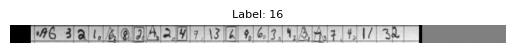

In [4]:
use_set = 'set2'
n = 50000
dataset_img_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "images")
dataset_lbl_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "labels")

img_paths, label_paths = load_dataset(dataset_img_path, dataset_lbl_path, n)
train_img_paths, test_img_paths, train_lbl_paths, test_lbl_paths = train_test_split(img_paths, label_paths, test_size=0.05, random_state=42, shuffle=True)

train_dataset = ScorecardDataset(train_img_paths, train_lbl_paths, tokenizer.char2idx)
test_dataset = ScorecardDataset(test_img_paths, test_lbl_paths, tokenizer.char2idx)
trainloader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=scorecard_collate_fn)
testloader = DataLoader(test_dataset, batch_size=4, shuffle=False, collate_fn=scorecard_collate_fn)

print(f"Dataset split complete: {len(train_dataset)} train, {len(test_dataset)} test.")

# Visualize 1 pair or image-label
batch = next(iter(trainloader))
images, targets, input_lengths, target_lengths = batch
img = images[0]
img = img.squeeze(0)
plt.imshow(img.numpy(), cmap='gray')
plt.title(f"Label: {targets[0]}", fontsize=8); plt.axis('off'); plt.show()

In [26]:
epochs = 15
train_losses, val_losses = [], []
best_val_loss = float('inf')
for e in range(epochs):
    train_loss = train_step(model, trainloader, optimizer, criterion, device)
    val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"--- Epoch {e} --- Train loss: {train_loss:.4f} | Validation loss: {val_loss:.4f} | cer: {val_acc:.3f}")
    # if (e+1)%50 == 0:
    # print(val_examples.to_string())

100%|██████████| 11875/11875 [19:16<00:00, 10.27it/s]


--- Epoch 0 --- Train loss: 1.4275 | Validation loss: 0.3594 | cer: 0.109


100%|██████████| 11875/11875 [11:26<00:00, 17.29it/s]


--- Epoch 1 --- Train loss: 0.2553 | Validation loss: 0.2105 | cer: 0.062


100%|██████████| 11875/11875 [11:22<00:00, 17.40it/s]


...

--- Epoch 12 --- Train loss: 0.0359 | Validation loss: 0.0421 | cer: 0.011


100%|██████████| 11875/11875 [11:21<00:00, 17.43it/s]


--- Epoch 13 --- Train loss: 0.0328 | Validation loss: 0.0390 | cer: 0.010


100%|██████████| 11875/11875 [11:20<00:00, 17.46it/s]


--- Epoch 14 --- Train loss: 0.0296 | Validation loss: 0.0285 | cer: 0.007


In [27]:
checkpoint = {
    "epoch": epochs,  #
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_losses,
    "validation_loss": val_losses,
    "description": 'batch size of 4 used' 
}

save_path = os.path.join(PROJECT_ROOT, "weights", "crnn_set2_N-50k")
os.makedirs(save_path, exist_ok=True)
cp_name = "checkpoint-15ep"
torch.save(checkpoint, os.path.join(save_path, f"{cp_name}.pt"))

In [ ]:
val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
for i, row in val_examples.sample(10).iterrows():
    print(f"GT: \t {row['Ground Truth']}")
    print(f"Pred: \t {row['Predicted']}")
    print()

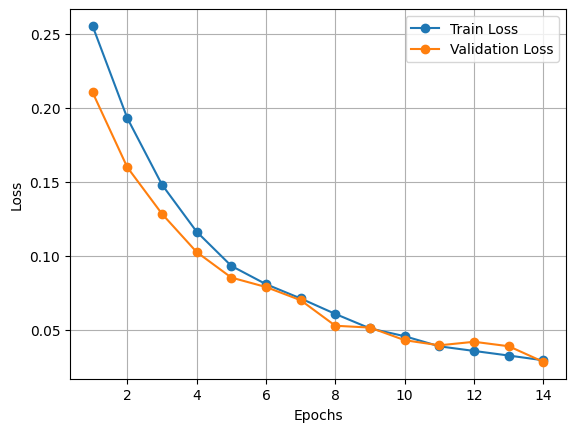

In [5]:
from scripts.utils import see_losses

see_losses("crnn_set2_N-50k", 1)

In [ ]:
from models.crnn.model_eval import real_data_eval

n_epochs = 15
cp_name = "checkpoint-15ep"
text_desc = f"""
Model {cp_name} trained on 15 epochs using Synthetic dataset 2.0 with 50k samples.
"""

real_data_eval(model, criterion, device, tokenizer, save_fig=f"crnn_set2_N-50k_{n_epochs}ep", print_text=text_desc)

## EXP 3 : CRNN 2.0 with dataset class 2.0

First version (discarded) of CRNN 2.0 trained with 10k samples on 15 epochs got an average CER of 0.367 on real samples. Its initial architecture uses a 5x3 kernel in the first convolutional layer which blurs the vertical features due to a larger receptive field early on. It also delayed the first max pool thus keeping a larger feature map but makes the LSTM's job harder due to not having distilled information into high-level features early enough.

Using 10k samples may be too little for the CRNN 2.0 since it has an additional layer that maps to 512 channels and is hence more data hungry. This can be reflected in the real sample evaluation, where the first improved version of this model trained with 10k samples on 25 epochs got an average CER of 0.404. Therefore, 50k samples are used with batch size 8 (GPU VRAM limits with added channel mapping). Since batch size is reduced, too many batch normalization becomes damaging. This did not yield good results, training became stagnant as the amount of tokens to be predicted by the LSTM is too much without width reductions.

In the second version that provided progression in performance, a total of 4 times `width_reduction` is used in the first two max pool layers. Slight changes were made to properly apply layer normalization across the channels. With width reduction, training has sped up and the LSTM was able to handle the load of tokens, GPU VRAM usage has also reduced from ~7MiB to just 1391MiB with a `batch_size` 8. The best average CER on real samples was 0.209 on 3 epochs, further training increased that value. Another change made was switching from the Adadelta optimizer to Adam due to the stagnant validation loss and CER, paired with a learning rate scheduler `ReduceLROnPlateau`.

With more GPU VRAM freed up:
- the same trial with `batch_size` 16 (3151MiB) was done, with the best average CER on real samples was 0.861 on the second epoch, this can be explained by the model requiring noisy gradients and more optimizer steps to learn well.
- moving back to `batch_size` 8, increasing `num_layers` in the LSTM to 3 gave stagnant loss.


In [17]:
from scripts.dataset_class import ScorecardDataset, scorecard_collate_fn, Tokenizer, load_dataset
importlib.reload(sys.modules['models.crnn.model_class'])
from models.crnn.model_class import CRNN2

tokenizer = Tokenizer()
num_classes = len(tokenizer.alphabet)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN2(num_classes).to(device)
criterion = nn.CTCLoss(blank=0, zero_infinity=True)
# optimizer = optim.Adadelta(model.parameters())
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [ ]:
# Test with real_dataset2

E = 3
opt = 'adadelta'
cp_name = f'checkpoint-{E}ep_{opt}'
model, optimizer, checkpoint = load_checkpoint('crnn2', 'crnn2_set2_N-50k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on {E} epochs using Synthetic dataset 2.0 with 50k samples.
Optimizer used was {opt}.
Test dataset 2.0 used for this evaluation.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset2'), width_reduction=4,
                         save_fig=f"crnn2_set2_N-50K_{E}ep_eval2", print_text=text_desc, show=False)
results

E:\work\Golf\GolfScoreCards\models\crnn\model_eval.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.8, 1, 1])


{'N': 52,
 'average_loss': 1.4141560059327345,
 'average_cer': 0.31723044308525117,
 'min_cer': 0.17647058823529413,
 'max_cer': 0.6226415094339622}

In [24]:
# Test with real_dataset2

E = 6
opt = 'adadelta'
cp_name = f'checkpoint-{E}ep_{opt}'
model, optimizer, checkpoint = load_checkpoint('crnn2', 'crnn2_set2_N-50k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on {E} epochs using Synthetic dataset 2.0 with 50k samples.
Optimizer used was {opt}.
Test dataset 2.0 used for this evaluation.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset2'), width_reduction=4,
                         save_fig=f"crnn2_set2_N-50K_{E}ep_eval2", print_text=text_desc, show=False)
results

E:\work\Golf\GolfScoreCards\models\crnn\model_eval.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.8, 1, 1])


{'N': 52,
 'average_loss': 1.360671268059657,
 'average_cer': 0.2426973508720303,
 'min_cer': 0.037037037037037035,
 'max_cer': 0.8214285714285714}

In [25]:
# Test with real_dataset2

E = 3
opt = 'adam+lr'
cp_name = f'checkpoint-{E}ep_{opt}'
model, optimizer, checkpoint = load_checkpoint('crnn2', 'crnn2_set2_N-50k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on {E} epochs using Synthetic dataset 2.0 with 50k samples.
Optimizer used was {opt}.
Test dataset 2.0 used for this evaluation.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset2'), width_reduction=4,
                         save_fig=f"crnn2_set2_N-50K_{E}ep_eval2", print_text=text_desc, show=False)
results

{'N': 52,
 'average_loss': 0.9777346918216119,
 'average_cer': 0.18620179768210487,
 'min_cer': 0.037037037037037035,
 'max_cer': 0.6071428571428571}

Dataset split complete: 47500 train, 2500 test.


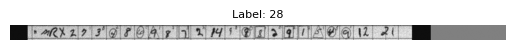

In [18]:
use_set = 'set2'
n = 50000
dataset_img_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "images")
dataset_lbl_path = os.path.join(PROJECT_ROOT, "syn_dataset", use_set, "labels")

img_paths, label_paths = load_dataset(dataset_img_path, dataset_lbl_path, n)
train_img_paths, test_img_paths, train_lbl_paths, test_lbl_paths = train_test_split(img_paths, label_paths, test_size=0.05, random_state=42, shuffle=True)

train_dataset = ScorecardDataset(train_img_paths, train_lbl_paths, tokenizer.char2idx)
test_dataset = ScorecardDataset(test_img_paths, test_lbl_paths, tokenizer.char2idx)
trainloader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=lambda x: scorecard_collate_fn(x, width_reduction=4))
testloader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=lambda x: scorecard_collate_fn(x, width_reduction=4))

print(f"Dataset split complete: {len(train_dataset)} train, {len(test_dataset)} test.")

# Visualize 1 pair or image-label
batch = next(iter(trainloader))
images, targets, input_lengths, target_lengths = batch
img = images[0]
img = img.squeeze(0)
plt.imshow(img.numpy(), cmap='gray')
plt.title(f"Label: {targets[0]}", fontsize=8); plt.axis('off'); plt.show()

In [11]:
torch.cuda.empty_cache()

In [19]:
epochs = 3
train_losses, val_losses = [], []
real_loss, real_cer = [], []
best_val_loss = float('inf')
for e in range(epochs):
    train_loss = train_step(model, trainloader, optimizer, criterion, device)
    val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    out_real = real_data_eval(model, criterion, device, tokenizer, False, False, width_reduction=4)
    real_loss.append(out_real['average_loss'])
    real_cer.append(out_real['average_cer'])

    print(f"--- Epoch {e} --- Train loss: {train_loss:.4f}  |  Validation loss: {val_loss:.4f}, cer: {val_acc:.3f}  |  Real loss: {out_real['average_loss']:.4f}, cer: {out_real['average_cer']:.3f}")
    # if (e+1)%50 == 0:
    # print(val_examples.to_string())

100%|██████████| 5938/5938 [05:59<00:00, 16.52it/s]


--- Epoch 0 --- Train loss: 0.9324  |  Validation loss: 0.1917, cer: 0.053  |  Real loss: 1.2439, cer: 0.280


100%|██████████| 5938/5938 [06:08<00:00, 16.12it/s]


--- Epoch 1 --- Train loss: 0.1412  |  Validation loss: 0.1119, cer: 0.033  |  Real loss: 1.0938, cer: 0.223


100%|██████████| 5938/5938 [06:02<00:00, 16.38it/s]


--- Epoch 2 --- Train loss: 0.0772  |  Validation loss: 0.0608, cer: 0.017  |  Real loss: 1.5394, cer: 0.282


In [ ]:
more_epochs = 3
for e in range(more_epochs):
    train_loss = train_step(model, trainloader, optimizer, criterion, device)
    val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
    # scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    out_real = real_data_eval(model, criterion, device, tokenizer, False, False, width_reduction=4)
    real_loss.append(out_real['average_loss'])
    real_cer.append(out_real['average_cer'])

    print(f"--- Epoch {e} --- Train loss: {train_loss:.4f}  |  Validation loss: {val_loss:.4f}, cer: {val_acc:.3f}  |  Real loss: {out_real['average_loss']:.4f}, cer: {out_real['average_cer']:.3f}")
    

100%|██████████| 5938/5938 [05:59<00:00, 16.53it/s]
E:\work\Golf\GolfScoreCards\models\crnn\model_eval.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.8, 1, 1])


--- Epoch 0 --- Train loss: 0.1504  |  Validation loss: 0.1077, cer: 0.032  |  Real loss: 1.7448, cer: 0.316


100%|██████████| 5938/5938 [06:08<00:00, 16.11it/s]


--- Epoch 1 --- Train loss: 0.0703  |  Validation loss: 0.0487, cer: 0.014  |  Real loss: 1.5126, cer: 0.277


100%|██████████| 5938/5938 [06:09<00:00, 16.09it/s]


--- Epoch 2 --- Train loss: 0.0450  |  Validation loss: 0.0390, cer: 0.012  |  Real loss: 1.4942, cer: 0.250


In [ ]:
checkpoint = {
    "epoch": epochs,  # change
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_loss": train_losses,
    "validation_loss": val_losses,
    "scheduler": scheduler.state_dict(),
    "description": 'Model update - 4x width reduction in first two max pool layers. Adam optimizer + ReduceLROnPlateau scheduler were used' 
}

save_path = os.path.join(PROJECT_ROOT, "weights", "crnn2_set2_N-50k")  # change
os.makedirs(save_path, exist_ok=True)
cp_name = "checkpoint-3ep_adam_2"  # change
torch.save(checkpoint, os.path.join(save_path, f"{cp_name}.pt"))

In [ ]:
val_loss, val_acc, val_examples = evaluate(model, testloader, criterion, device, tokenizer)
for i, row in val_examples.sample(10).iterrows():
    print(f"GT: \t {row['Ground Truth']}")
    print(f"Pred: \t {row['Predicted']}")
    print()

In [27]:
E = 6
opt = 'adadelta'
cp_name = f'checkpoint-{E}ep_{opt}'
model, optimizer, checkpoint = load_checkpoint('crnn2', 'crnn2_set2_N-50k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on {E} epochs using Synthetic dataset 2.0 with 50k samples.
Optimizer used was {opt}.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset'), width_reduction=4,
                         save_fig=f"crnn2_set2_N-50K_{E}ep", print_text=text_desc, show=False)
results

{'N': 40,
 'average_loss': 1.4941616117954255,
 'average_cer': 0.24980027113821562,
 'min_cer': 0.05454545454545454,
 'max_cer': 0.8214285714285714}

In [28]:
E = 3
opt = 'adam+lr'
cp_name = f'checkpoint-{E}ep_{opt}'
model, optimizer, checkpoint = load_checkpoint('crnn2', 'crnn2_set2_N-50k', cp_name, num_classes)
text_desc = f"""
Model {cp_name} trained on {E} epochs using Synthetic dataset 2.0 with 50k samples.
Optimizer used was {opt}.
"""
results = real_data_eval(model, criterion, device, tokenizer, real_datadir=os.path.join(PROJECT_ROOT, 'real_dataset'), width_reduction=4,
                         save_fig=f"crnn2{opt}_set2_N-50K_{E}ep", print_text=text_desc, show=False)
results

E:\work\Golf\GolfScoreCards\models\crnn\model_eval.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout(rect=[0, 0.8, 1, 1])


{'N': 40,
 'average_loss': 1.261521762609482,
 'average_cer': 0.20933795886247814,
 'min_cer': 0.05454545454545454,
 'max_cer': 0.6071428571428571}